In [1]:
from nbed.utils import pubchem_mol_geometry, save_ordered_xyz_file

mol_name = "formamide"

save_ordered_xyz_file(mol_name, pubchem_mol_geometry(mol_name), [0])

'/Users/michaelwilliamsdelabastida/Code/Nbed/docs/notebooks/molecular_structures/formamide.xyz'

In [23]:
"""Tools to plot molecular orbitals."""

import logging
import os
from typing import List

import numpy as np
import py3Dmol
from pyscf import gto
from pyscf.tools import cubegen

logger = logging.getLogger(__name__)


def Draw_molecule(
    xyz_string: str, width: int = 400, height: int = 400, style: str = "sphere"
) -> py3Dmol.view:
    """Draw molecule from xyz string.

    Note if molecule has unrealistic bonds, then style should be sphere. Otherwise stick style can be used
    which shows bonds.

    TODO: more styles at http://3dmol.csb.pitt.edu/doc/$3Dmol.GLViewer.html

    Args:
        xyz_string (str): xyz string of molecule
        width (int): width of image
        height (int): Height of image
        style (str): py3Dmol style ('sphere' or 'stick')

    Returns:
        view (py3dmol.view object). Run view.show() method to print molecule.
    """
    logger.debug("Drawing molecule.")
    if style == "sphere":
        view = py3Dmol.view(
            data=xyz_string,
            style={"sphere": {"radius": 0.2}},
            width=width,
            height=height,
        )
    elif style == "stick":
        view = py3Dmol.view(
            data=xyz_string, style={"stick": {}}, width=width, height=height
        )
    else:
        raise ValueError(f"unknown py3dmol style: {style}")

    view.zoomTo()
    return view


def draw_cube_orbital(
    PySCF_mol_obj: gto.Mole,
    xyz_string: str,
    C_matrix: np.ndarray,
    index_list: List[int],
    width: int = 400,
    height: int = 400,
    style: str = "sphere",
) -> List:
    """Draw orbials given a C_matrix and xyz string of molecule.

    This function writes orbitals to tempory cube files then deletes them.
    For standard use the C_matrix input should be C_matrix optimized by a self consistent field (SCF) run.
    Note if molecule has unrealistic bonds, then style should be set to sphere.

    Args:
        PySCF_mol_obj (pyscf.mol): PySCF mol object. Required for pyscf.tools.cubegen function
        xyz_string (str): xyz string of molecule
        C_matrix (np.array): Numpy array of molecular orbitals (columns are MO).
        index_list (List): List of MO indices to plot
        width (int): width of image
        height (int): Height of image
        style (str): py3Dmol style ('sphere' or 'stick')

    Returns:
        plotted_orbitals (List): List of plotted orbitals (py3Dmol.view) ordered the same way as in index_list
    """
    logger.debug("Drawing cube orbital.")
    if not set(index_list).issubset(set(range(C_matrix.shape[1]))):
        raise ValueError(
            "list of MO indices to plot is outside of C_matrix column indices"
        )

    plotted_orbitals = []
    for index in index_list:
        File_name = f"temp_MO_orbital_index{index}.cube"
        cubegen.orbital(PySCF_mol_obj, File_name, C_matrix[:, index])

        view = py3Dmol.view(width=width, height=height)
        view.addModel(xyz_string, "xyz")
        if style == "sphere":
            view.setStyle({"sphere": {"radius": 0.2}})
        elif style == "stick":
            view.setStyle({"stick": {}})
        else:
            raise ValueError(f"unknown py3dmol style: {style}")

        with open(File_name, "r") as f:
            view.addVolumetricData(
                f.read(), "cube", {"isoval": -0.02, "color": "red", "opacity": 0.75}
            )
        with open(File_name, "r") as f2:
            view.addVolumetricData(
                f2.read(), "cube", {"isoval": 0.02, "color": "blue", "opacity": 0.75}
            )

        plotted_orbitals.append(view.zoomTo())
        os.remove(File_name)  # delete file once orbital is drawn

    return plotted_orbitals

In [ ]:
print(param())

NameError: name 'param_eigen' is not defined

In [42]:
print(param_zundel())


        O	0	0	0
        H	1.25	0	0
        O	2.5	0	0
        H	-0.5967028259526409	0.7634693002995727	0
        H	-0.5967028259526409	-0.7634693002995727	0
        H	3.096702825952641	0.7634693002995727	0
        H	3.096702825952641	-0.7634693002995727	0
        


In [70]:
geom ="""5
 
        H	0	1.151	-0.9024
        F	-1.089	-0.2682	0
        F	1.089	-0.2682	0
        C	0	0.5363	0
        H	0	1.151	0.9024
"""

Draw_molecule(geom, style="sphere")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [22]:
from nbed.utils import *

In [2]:
import logging
import os
from functools import cached_property
from typing import Callable, Optional, Tuple, Union

import numpy as np
from pyscf import cc, dft, fci, gto, qmmm, scf
from pyscf.lib import StreamObject

from nbed.exceptions import NbedConfigError
from nbed.localizers import (
    BOYSLocalizer,
    IBOLocalizer,
    PMLocalizer,
    SPADELocalizer,
)

from nbed.scf import energy_elec, huzinaga_scf

# Create the Logger
logger = logging.getLogger(__name__)


In [ ]:
from nbed.driver import NbedDriver
from nbed.ham_builder import HamiltonianBuilder

def param_zundel(percent:float =.5):
    geom = f"""
        O	0	0	0
        H	{percent * 2.5}	0	0
        O	2.5	0	0
        H	-0.5967028259526409	0.7634693002995727	0
        H	-0.5967028259526409	-0.7634693002995727	0
        H	3.096702825952641	0.7634693002995727	0
        H	3.096702825952641	-0.7634693002995727	0
        """
    return geom

In [ ]:
params = np.linspace(0.1,0.9,20)
vals = {param : {} for param in params}
for param in params:
    args = {
        "geometry":param_zundel(param),
        "n_active_atoms":3,
        "basis":"sto-3g",
        "projector":"both",
        "xc_functional":"b3lyp",
        "spin":1,
        "charge":0,
        "run_ccsd_emb":True,
            }
    
    driver = NbedDriver(**args)
    vals[param]["args"] = args

    vals[param]["e_classical"] = driver.classical_energy
    vals[param]["e_hf"] = driver._global_hf.e_tot
    vals[param]["e_dft"] = driver._global_ks.e_tot
    vals[param]["e_fci"] = driver._global_fci.e_tot
    vals[param]["e_ccsd"] = driver._global_ccsd.e_tot
    
    vals[param]["mu_ccsd"] = driver._mu["e_ccsd"]
    vals[param]["huz_ccsd"] = driver._huzinaga["e_ccsd"]

    mu_hb = HamiltonianBuilder(driver._mu["scf"], driver.classical_energy)
    vals[param]["mu_one_e"] = mu_hb._one_body_integrals
    vals[param]["mu_two_e"] = mu_hb._two_body_integrals

    huz_hb = HamiltonianBuilder(driver._huzinaga["scf"], driver.classical_energy)
    vals[param]["huz_one_e"] = huz_hb._one_body_integrals
    vals[param]["huz_two_e"] = huz_hb._two_body_integrals

    # vals[param]



Initialize <pyscf.gto.mole.Mole object at 0x15df9a350> in <pyscf.dft.rks.RKS object at 0x15e1c8950>
Initialize <pyscf.gto.mole.Mole object at 0x15e042290> in <pyscf.dft.rks.RKS object at 0x15e413810>
2025-04-09 20:17:12,789: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.
Initialize <pyscf.gto.mole.Mole object at 0x15e244490> in <pyscf.dft.rks.RKS object at 0x15e01ffd0>
Initialize <pyscf.gto.mole.Mole object at 0x15e0aa1d0> in <pyscf.dft.rks.RKS object at 0x15de3e610>
2025-04-09 20:17:31,177: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.
Initialize <pyscf.gto.mole.Mole object at 0x15dd093d0> in <pyscf.dft.rks.RKS object at 0x15e01ffd0>
Initialize <pyscf.gto.mole.Mole object at 0x15d4d53d0> in <pyscf.dft.rks.RKS object at 0x1696e0e10>
2025-04-09 20:17:49,050: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.
Initialize <pyscf.gto.mole.Mole object at 0x15de88d90> in <pyscf.dft.rks.RKS ob

In [18]:
import pandas as pd

df = pd.DataFrame.from_dict(vals)

In [19]:
df.T["e_classical"]

0.100000       (45.4252859316879, 45.4252859317086)
0.142105      (40.43912814167323, 40.4391281416187)
0.184211    (37.764609387664585, 37.76460938770853)
0.226316    (36.11148283524732, 36.111482835526886)
0.268421     (34.98240786307569, 34.98240786287587)
0.310526      (34.1247233419568, 34.12472334203269)
0.352632    (33.40043347332241, 33.400433473152276)
0.394737     (32.79059917123497, 32.79059917112127)
0.436842     (32.34283925914283, 32.34283925908987)
0.478947    (32.10466963473124, 32.104669634578364)
0.521053     (32.10466963449842, 32.10466963457841)
0.563158    (32.342839258851804, 32.34283925908994)
0.605263     (32.79059917135143, 32.79059917112141)
0.647368    (33.400433473089635, 33.40043347315222)
0.689474    (34.12472334195671, 34.124723342032695)
0.731579    (34.98240786307575, 34.982407862875974)
0.773684     (36.11148283577123, 36.11148283552696)
0.815789    (37.76460938760641, 37.764609387708596)
0.857895     (40.43912814149867, 40.43912814161879)
0.900000    

<Axes: >

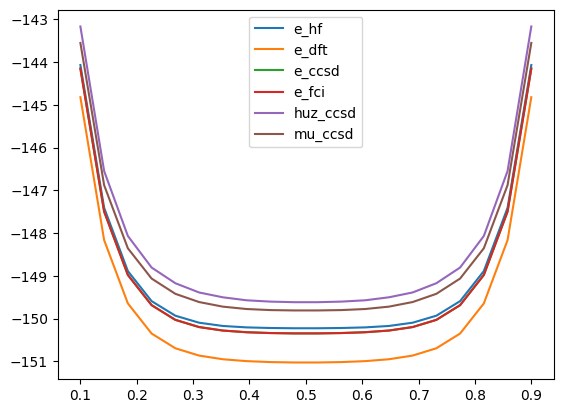

In [21]:
df.T[["e_hf","e_dft","e_ccsd","e_fci","huz_ccsd","mu_ccsd"]].plot()

In [39]:
from nbed.driver import NbedDriver
from nbed.ham_builder import HamiltonianBuilder

def param_eigen(percent:float =.5):
    geom = f"""
        O    0.00000000  0.00000000  0.00000000
        H    0.00000000  {2.31089400 * percent} {-0.66055200 * percent}
        O    0.00000000  2.31089400 -0.66055200
        H   -0.84226100 -0.51021700 -0.27677000
        H    0.86299200 -0.47431100 -0.27677000
        H   -0.73965500  2.67474100 -1.19404100
        H    0.14116400  2.98501800  0.03906200
        O   -2.00129300 -1.15544700 -0.66055200
        H   -1.94656600 -1.97793000 -1.19404100
        H   -2.65568400 -1.37025700  0.03906200
        O    2.00129300 -1.15544700 -0.66055200
        H    2.51452000 -1.61476100  0.03906200
        H    2.68622100 -0.69681000 -1.19404100
        """
    return geom

In [55]:
driver._global_hf().mol.nao

np.int64(15)

In [ ]:
params = np.linspace(0.1,0.9,20)
eigen_vals = {param : {} for param in params}
for param in params:
    print(param)
    args = {
        "geometry":param_zundel(param),
        "n_active_atoms":3,
        "basis":"sto-3g",
        "projector":"both",
        "xc_functional":"b3lyp",
        "spin":1,
        "charge":0,
        "run_ccsd_emb":True,
            }
    
    try:
        driver = NbedDriver(**args)
    except np.linalg.LinAlgError:
        print("uh oh")
        continue
    
    eigen_vals[param]["args"] = args


    eigen_vals[param]["e_classical"] = driver.classical_energy
    eigen_vals[param]["e_hf"] = driver._global_hf.e_tot
    eigen_vals[param]["e_dft"] = driver._global_ks.e_tot
    # vals[param]["e_fci"] = driver._global_fci.e_tot
    eigen_vals[param]["e_ccsd"] = driver._global_ccsd.e_tot
    
    eigen_vals[param]["mu_ccsd"] = driver._mu["e_ccsd"]
    # eigen_vals[param]["huz_ccsd"] = driver._run_emb_CCSD(driver._huzinaga["scf"], None)

    mu_hb = HamiltonianBuilder(driver._mu["scf"], driver.classical_energy)
    eigen_vals[param]["mu_one_e"] = mu_hb._one_body_integrals
    eigen_vals[param]["mu_two_e"] = mu_hb._two_body_integrals

    # huz_hb = HamiltonianBuilder(driver._huzinaga["scf"], driver.classical_energy)
    # eigen_vals[param]["huz_one_e"] = huz_hb._one_body_integrals
    # eigen_vals[param]["huz_two_e"] = huz_hb._two_body_integrals

    # vals[param]

0.1


Initialize <pyscf.gto.mole.Mole object at 0x15e1ec450> in <pyscf.dft.rks.RKS object at 0x15e0bf110>
Initialize <pyscf.gto.mole.Mole object at 0x15ddeca50> in <pyscf.dft.rks.RKS object at 0x15be8ec50>
2025-04-09 21:22:05,678: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


0.14210526315789473


Initialize <pyscf.gto.mole.Mole object at 0x15e219090> in <pyscf.dft.rks.RKS object at 0x15beab210>
Initialize <pyscf.gto.mole.Mole object at 0x15e451d50> in <pyscf.dft.rks.RKS object at 0x15e452190>
2025-04-09 21:22:06,767: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


0.1842105263157895


...

Initialize <pyscf.gto.mole.Mole object at 0x15e090a90> in <pyscf.dft.rks.RKS object at 0x15e20a210>
Initialize <pyscf.gto.mole.Mole object at 0x15bd83350> in <pyscf.dft.rks.RKS object at 0x15bd4dad0>
2025-04-09 21:22:23,661: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


0.8578947368421053


Initialize <pyscf.gto.mole.Mole object at 0x15e0f4450> in <pyscf.dft.rks.RKS object at 0x15e1cbed0>
Initialize <pyscf.gto.mole.Mole object at 0x15e0a7650> in <pyscf.dft.rks.RKS object at 0x14ef3e1d0>
2025-04-09 21:22:24,747: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


0.9


Initialize <pyscf.gto.mole.Mole object at 0x15e21aa10> in <pyscf.dft.rks.RKS object at 0x15bd03f90>
Initialize <pyscf.gto.mole.Mole object at 0x15e08f650> in <pyscf.dft.rks.RKS object at 0x15de1c310>
2025-04-09 21:22:25,821: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


In [51]:
[ones.shape for ones in eigen_df.T["mu_one_e"]]

[(2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14),
 (2, 14, 14)]

<Axes: >

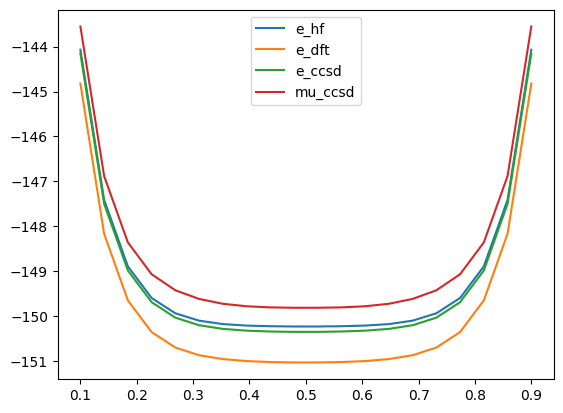

In [48]:
eigen_df = pd.DataFrame.from_dict(eigen_vals)
eigen_df.T[["e_hf","e_dft","e_ccsd","mu_ccsd"]].plot()

In [ ]:
from pyscf.fci import FCI
from openfermion import get_sparse_operator
import scipy as sp

ham = hb.build()
diag, _ = sp.sparse.linalg.eigsh(get_sparse_operator(ham), k=2, which="SA")
print(mycc.e_tot + driver.classical_energy - driver._mu["scf"].energy_nuc())
print(diag)



2025-04-09 16:47:58,095: nbed.ham_builder: WARNING: Tapering is deprecated. Use the qubit_reduction_driver.


KeyboardInterrupt: 

In [ ]:
driver._global_ks().kernel()

np.float64(-75.30914474061156)

# Create Nbed output for Ferrmion

In [60]:
from nbed.driver import NbedDriver
from nbed.ham_builder import HamiltonianBuilder

def param_zundel(percent:float =.5):
    geom = f"""
        O	0	0	0
        H	{percent * 2.5}	0	0
        O	2.5	0	0
        H	-0.5967028259526409	0.7634693002995727	0
        H	-0.5967028259526409	-0.7634693002995727	0
        H	3.096702825952641	0.7634693002995727	0
        H	3.096702825952641	-0.7634693002995727	0
        """
    return geom

driver = NbedDriver(**args, geometry=param_zundel())

Initialize <pyscf.gto.mole.Mole object at 0x15be330d0> in <pyscf.dft.rks.RKS object at 0x15beeffd0>
Initialize <pyscf.gto.mole.Mole object at 0x158476e10> in <pyscf.dft.rks.RKS object at 0x158477690>
2025-04-11 11:33:42,084: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


In [64]:
hb = HamiltonianBuilder(driver._mu["scf"], driver.classical_energy)
hb._one_body_integrals

import pickle
with open("ones.pkl", "wb") as file:
    pickle.dump(hb._one_body_integrals, file)

In [65]:

import pickle
with open("twos.pkl", "wb") as file:
    pickle.dump(hb._two_body_integrals, file)